# Exercise 7 - Bagging and Boosting

In this exercise we will learn how to use an ensemble of weak learners to create a strong learner.
Bagging and Boosting will combine weak learners high variance and high bias respectively to a strong learner. 

In the event of a persistent problem, do not hesitate to contact the course instructor under

- maurice.wenig@uni-jena.de

### Submission
- Deadline of submission: 15.06.2026 23:59
- Submission on [moodle page](https://moodle.uni-jena.de/course/view.php?id=76636)


# Dataset

Similar to last exercise, we will use a synthetic dataset for binary classification created with scikit learn (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)).

### Task 1

Load and display the data located in `X.npy` and `y.npy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# load and display data
x = np.load('X.npy')
y = np.load('y.npy')

# assertions
assert x.shape == (500, 2)
assert y.shape == (500,)

# Model

We will use decision trees as our model, since Bagging and Boosting have first been developed for these models. Note however that we could in principle replace the decision tree with any other classificator.

### Task 2

Use scikit learn to learn a decision tree on the dataset, calculate the accuracy and display the decision boundary (you can use `utils.py`).

Single Decision Tree Training Accuracy: 1.0000


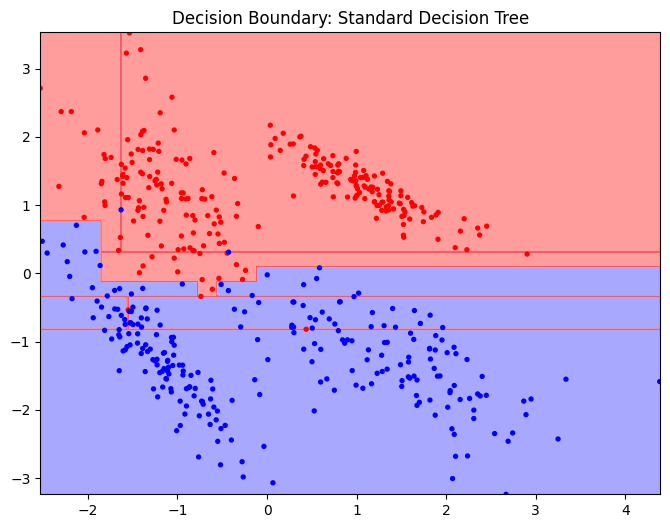

In [2]:
from sklearn.tree import DecisionTreeClassifier
from utils import plot_decision_boundary

# Initialize and train a standard Decision Tree classifier
dt_clf = DecisionTreeClassifier(random_state=0)
dt_clf.fit(x, y)

# Calculate and print the accuracy on the training set
accuracy = dt_clf.score(x, y)
print(f"Single Decision Tree Training Accuracy: {accuracy:.4f}")

# Plot the decision boundary using the provided utility function
plt.figure(figsize=(8, 6))
plot_decision_boundary(x, y, dt_clf)
plt.title("Decision Boundary: Standard Decision Tree")
plt.show()

# Crossvalidation

Until now, we used a train-test split of our data to evaluate how well a model generalizes on unseen data.
The test error is however greatly affected by the split. We could have a really bad split, where the test data is fundamentally different from the training data.

To overcome this issue, one typically uses **Crossvalidation** - a process where we average the performance of a model on the test data of multiple splits.

A commonly used procedure is called [**k-fold Crossvalidation**](https://en.wikipedia.org/wiki/Cross-validation_(statistics)#k-fold_cross-validation):

1. Shuffle the dataset
2. Split the dataset into $k$ equal sized parts
3. For $i = 1,\dots,k$:\
    i) Use part $i$ as testdata, the other parts as trainingdata\
    ii) Train model on traindata\
    iii) Test model on testdata, save test score
4. Report all $k$ test scores


### Task 3

Implement the following cross validation function and evaluate the average crossvalidation score for the decision tree from Task 2 with $k = 10$.

In [3]:
import numpy.typing as npt


def crossvalidation(estimator, x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_], n_splits: int, seed: int = 0) -> npt.NDArray[np.float64]:
    """Performs k-fold crossvalidation of an estimator.

    Parameters
    ----------
    estimator
        Object that has .fit(x,y), .predict(x) and .score(x,y) methods.
    x : npt.NDArray[np.float64]
        Features, shape (n_samples, n_features).
    y : npt.NDArray[np.bool_]
        Labels, shape (n_samples,).
    n_splits : int
        Number of splits.
    seed : int, optional
        Used for seeding before the shuffle, by default 0

    Returns
    -------
    npt.NDArray[np.float64]
        List with test scores for each of the k splits.
    """
    np.random.seed(seed)
    n_samples = x.shape[0]
    
    # 1. Shuffle the dataset indices to ensure random distribution across folds
    indices = np.random.permutation(n_samples)
    x_shuffled, y_shuffled = x[indices], y[indices]
    
    # 2. Calculate the size of each fold, distributing remainders evenly
    fold_sizes = np.full(n_splits, n_samples // n_splits, dtype=int)
    fold_sizes[:n_samples % n_splits] += 1
    
    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        folds.append((start, stop))
        current = stop
        
    cv_scores = []
    
    # 3. Iterate over each fold
    for start, stop in folds:
        # i) Isolate the current fold to act as test data
        x_test = x_shuffled[start:stop]
        y_test = y_shuffled[start:stop]
        
        # Isolate the remaining folds to act as training data
        x_train = np.concatenate((x_shuffled[:start], x_shuffled[stop:]))
        y_train = np.concatenate((y_shuffled[:start], y_shuffled[stop:]))
        
        # ii) Train the model on the training data
        estimator.fit(x_train, y_train)
        
        # iii) Evaluate the model on the test data and store the score
        score = estimator.score(x_test, y_test)
        cv_scores.append(score)
        
    return np.array(cv_scores)


# calculate avg. CV score for k = 10
dt_clf_cv = DecisionTreeClassifier(random_state=0)
cv_scores = crossvalidation(dt_clf_cv, x, y, n_splits=10)
print(f"Custom CV Average Score (k=10): {np.mean(cv_scores):.4f}")

# assertions
assert len(cv_scores) == 10

Custom CV Average Score (k=10): 0.9600


### Task 4

In the following we want to use scikit learn to perform crossvalidation.

Use scikit learns [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) function to perform a 10-fold crossvalidation, similar to Task 3.
Again report the average crossvalidation score.


In [4]:
from sklearn.model_selection import cross_val_score

# Calculate crossvalidation scores utilizing scikit-learn's built-in functionality
dt_clf_sklearn = DecisionTreeClassifier(random_state=0)
sklearn_cv_scores = cross_val_score(dt_clf_sklearn, x, y, cv=10)

print(f"Sklearn CV Average Score (k=10): {np.mean(sklearn_cv_scores):.4f}")

Sklearn CV Average Score (k=10): 0.9580


# Bagging - Variance Reduction

In Bagging we have learners with **high variance**. 

<div>
<img src="images/bagging.png" width="700"/>
</div>

The idea is now to learn multiple of these weak learners **in parallel** and use an aggregated decision from all learners for prediction. The hope is that, this way, the ensemble can overthrow the overfit of a single learner.

## Bootstrapping

Since we would get the same learner each time if we learn on the same data, each learner is trained on a **bootstrap** dataset.

The idea is simple: Draw samples at random from the original dataset.

### Task 5

Implement the bootstrap function. Use it to sample a bootstrap dataset and display the densities of the original and bootstrap data. You can use `utils.plot_density` or create your own visualization.

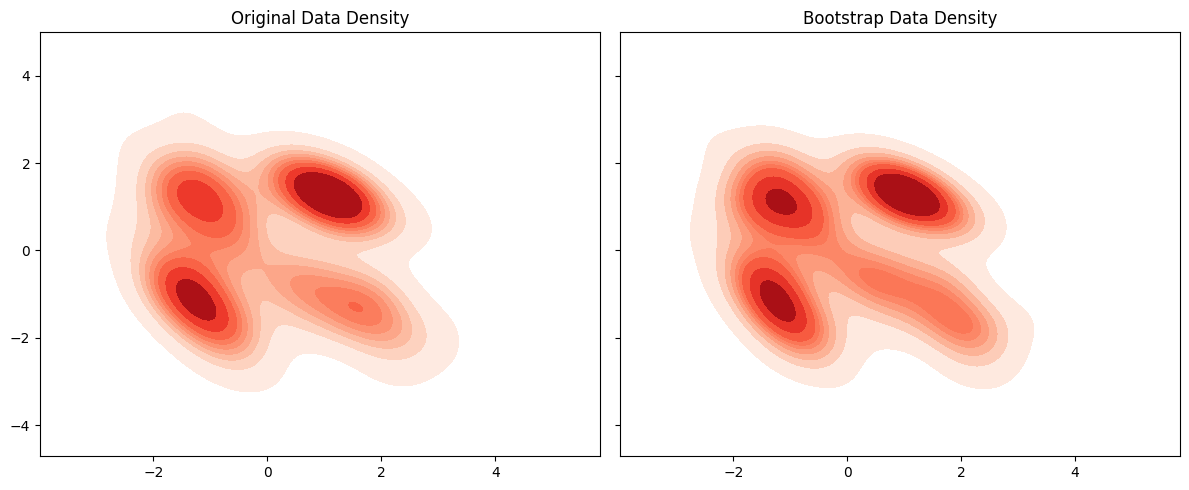

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from utils import plot_decision_boundary, plot_density


def sample_bootstrap(x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_], n_samples: int) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.bool_]]:
    """Creates a bootstrap dataset.

    Parameters
    ----------
    x : npt.NDArray[np.float64]
        Features, shape (n_samples, n_features).
    y : npt.NDArray[np.bool_]
        Labels, shape (n_samples,).
    n_samples : int
        Number of samples in bootstrap dataset.

    Returns
    -------
    tuple[npt.NDArray[np.float64], npt.NDArray[np.bool_]]
        x, y of bootstrap dataset.
    """

    # Draw random indices from the original dataset with replacement
    indices = np.random.choice(x.shape[0], size=n_samples, replace=True)
    return x[indices], y[indices]


# draw bootstrap dataset
np.random.seed(0)
x_boot, y_boot = sample_bootstrap(x, y, n_samples=x.shape[0])

# visualize distribution of bootstrap and original data
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].set_title("Original Data Density")
plot_density(x, ax=axes[0])

axes[1].set_title("Bootstrap Data Density")
plot_density(x_boot, ax=axes[1])

plt.tight_layout()
plt.show()

## Bootstrap Aggregation

Bagging now involves the two steps:

1. **Training**: Train $k$ learners on bootstrapped datasets (with the same size as the original dataset).
2. **Prediction**: Output the class label that most of the $k$ learners predict (majority vote).

### Task 6

Implement the Bagging class for decision trees. 

Use scikit learn to compute the crossvalidation scores ($k = 10$) for Bagging with 10 decision trees and maximum depth of 10.


**Note**:
- remember to empty the tree list for each fit. Otherwise crossvalidation will always append to this list.
- in order to use your own class in `cross_val_score` just inherit from `sklearn.base.BaseEstimator` and implement `fit` and `score`.

In [ ]:
from typing_extensions import Self
from sklearn.base import BaseEstimator


class DecisionTreeBagging(BaseEstimator):
    def __init__(self, n_trees: int, **kwargs):
        """Learns ensemble of decision trees with Bagging.

        Parameters
        ----------
        n_trees : int
            Number of decision trees in ensemble.
        **kwargs
            Keyword arguments for DecisionTreeClassifier, such as max_depth. Passed to decision tree creation with `DecisionTreeClassifier(**self.kwargs)`.
        """

        self.n_trees = n_trees
        self.kwargs = kwargs
        self.trees: list[DecisionTreeClassifier] = []

    def fit(self, x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_]) -> Self:
        """Learns ensemble of decision trees with Bagging.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).
        y : npt.NDArray[np.bool_]
            Labels, shape (n_samples,).
        """

        # Empty the tree list on each fit to prevent appending over multiple CV runs
        self.trees = []
        
        for _ in range(self.n_trees):
            # Create a bootstrap dataset
            x_boot, y_boot = sample_bootstrap(x, y, n_samples=x.shape[0])
            
            # Train a tree on the bootstrap data and append to the ensemble
            tree = DecisionTreeClassifier(**self.kwargs)
            tree.fit(x_boot, y_boot)
            self.trees.append(tree)
            
        return self

    def predict(self, x: npt.NDArray[np.float64]) -> npt.NDArray[np.bool_]:
        """Given features, predicts labels.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).

        Returns
        -------
        npt.NDArray[np.bool_]
            Predicted labels, shape (n_samples,).
        """
        # Collect boolean predictions from all individual trees
        predictions = np.array([tree.predict(x) for tree in self.trees])
        
        # Calculate majority vote: if mean > 0.5, majority predicted True
        majority_vote = np.mean(predictions, axis=0) > 0.5
        return majority_vote

    def score(self, x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_]) -> float:
        """Accuracy, needed for crossvalidation.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).
        y : npt.NDArray[np.bool_]
            True labels, shape (n_samples,).

        Returns
        -------
        float
            Accuracy between the true labels and the labels predicted with x.
        """

        return np.mean(self.predict(x) == y)


np.random.seed(0)
# crossvalidation 10 trees, max_depth 10, k = 10
bagging_model = DecisionTreeBagging(n_trees=10, max_depth=10)
bagging_cv_scores = cross_val_score(bagging_model, x, y, cv=10)

print(f"Bagging CV Average Score: {np.mean(bagging_cv_scores):.4f}")

Bagging CV Average Score: 0.9720


### Task 7

For an increasing number of trees in the ensemble, track the average crossvalidation score over 10 tries.
Again, use $k = 10$ folds and a maximum depth of 10.

That is, for a fixed number of trees, calculate 10 average cv scores, each over 10 folds.

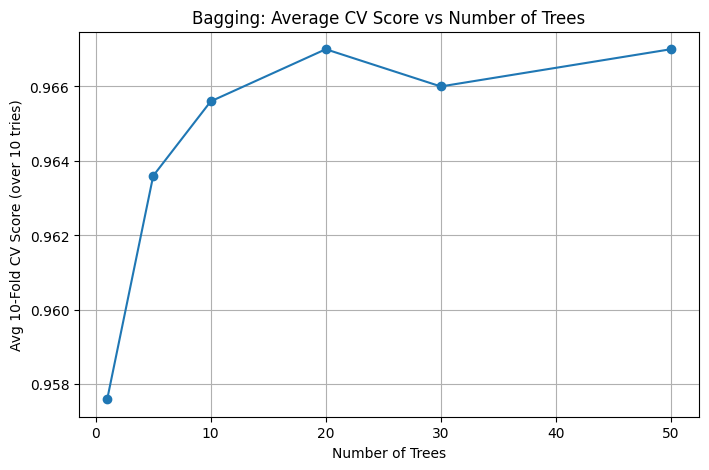

In [7]:
# increase number of trees, track avg. CV score over 10 tries
n_trees_list = [1, 5, 10, 20, 30, 50]
avg_scores = []

for n_trees in n_trees_list:
    run_scores = []
    for _ in range(10): # Average over 10 independent tries
        model = DecisionTreeBagging(n_trees=n_trees, max_depth=10)
        cv_scores = cross_val_score(model, x, y, cv=10)
        run_scores.append(np.mean(cv_scores))
    avg_scores.append(np.mean(run_scores))

plt.figure(figsize=(8, 5))
plt.plot(n_trees_list, avg_scores, marker='o')
plt.title("Bagging: Average CV Score vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Avg 10-Fold CV Score (over 10 tries)")
plt.grid(True)
plt.show()

# Boosting - Bias Reduction

In Boosting we have learners with **high bias**. 

<div>
<img src="images/boosting.png" width="700"/>
</div>

The idea is here to learn multiple of these weak learners **in sequence** and use an aggregated decision from all learners for prediction. Each learner learns on data where the previous learner failed. The hope is that this way we can get finer decisions.

### Task 8

Use scikit learn to learn a decision tree with high bias on the data. Again display the decision boundary.

High Bias Tree Accuracy: 0.9640


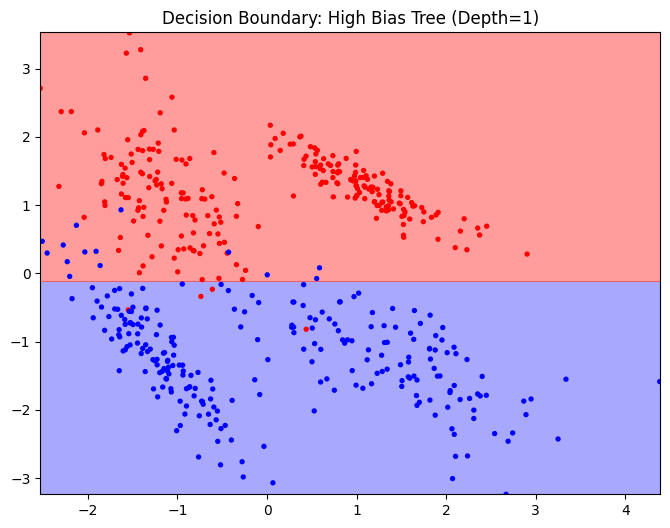

In [8]:
# Learn decision tree with high bias by severely restricting max depth (Decision Stump)
high_bias_tree = DecisionTreeClassifier(max_depth=1, random_state=0)
high_bias_tree.fit(x, y)

print(f"High Bias Tree Accuracy: {high_bias_tree.score(x, y):.4f}")

# Display decision boundary to visualize the high bias (likely a single split)
plt.figure(figsize=(8, 6))
plot_decision_boundary(x, y, high_bias_tree)
plt.title("Decision Boundary: High Bias Tree (Depth=1)")
plt.show()

## Weighted Samples

Each learner $L_{k}$ assigns different importance to samples depending on its predecessor learner $L_{k-1}$. This importance is realized by assigning a weight to each sample.

Let $L$ be a learner and $w$ be the vector of weights for each sample.

Then we define the weighted accuracy as 

\begin{align}
\text{Acc}_w = \cfrac{\sum_{i=1}^m w_i\cdot \mathbb{1}[L(x_i)=y_i]}{\sum_{i=1}^m w_i}\,,
\end{align}

where $\mathbb{1}$ is the indicator function.

### Task 9

Implement the following function and calculate the weighted accuracy for the decision tree from task 8 if we assume equal weights for each sample.

In [9]:
def weighted_accuracy(x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_], estimator, weights: npt.NDArray[np.float64]) -> float:
    """Calculates weighted accuracy.

    Parameters
    ----------
    x : npt.NDArray[np.float64]
        Features, shape (n_samples, n_features).
    y : npt.NDArray[np.bool_]
        Labels, shape (n_samples,).
    estimator : _type_
        Object with .predict(x) function.
    weights : npt.NDArray[np.float64]
        Weights for each sample in x, shape (n_samples,).

    Returns
    -------
    float
        Weighted accuracy.
    """

    # Get standard predictions from the estimator
    preds = estimator.predict(x)
    
    # Calculate the indicator: 1 if prediction matches label, 0 otherwise
    correct_indicator = (preds == y).astype(float)
    
    # Return the weighted sum of correct predictions normalized by total weights
    return np.sum(weights * correct_indicator) / np.sum(weights)


# calculate weighted accuracy
equal_weights = np.ones(len(x)) / len(x)
w_acc = weighted_accuracy(x, y, high_bias_tree, equal_weights)
print(f"Weighted Accuracy: {w_acc:.4f}")

assert np.isclose(weighted_accuracy(x, y, high_bias_tree, equal_weights), np.mean(high_bias_tree.predict(x) == y))

Weighted Accuracy: 0.9640


## Importance of say

Learners with high accuracy should have more say in the final decision.

The so called **importance of say** is defined as:

\begin{align*}
\alpha = \log\left(\cfrac{\text{Acc}_w}{1 - \text{Acc}_w}\right)\,.
\end{align*}

### Task 10

Implement the following function and calculate the importance of say of the decision tree on the dataset with equal weights.

Make sure the function does not fail in the extreme cases $\text{Acc}_w = 0$ and $\text{Acc}_w = 1$.

In [10]:
EPSILON = 1e-5


def importance_of_say(x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_], estimator, weights: npt.NDArray[np.float64]) -> float:
    """Calculates importance of say for the given estimator.

    Parameters
    ----------
    x : npt.NDArray[np.float64]
        Features, shape (n_samples, n_features).
    y : npt.NDArray[np.bool_]
        Labels, shape (n_samples,).
    estimator : _type_
        Object with .predict(x) function.
    weights : npt.NDArray[np.float64]
        Weights for each sample in x, shape (n_samples,).

    Returns
    -------
    npt.NDArray[np.float64]
        Importance of say for the given estimator.
    """

    # Obtain the weighted accuracy
    acc_w = weighted_accuracy(x, y, estimator, weights)
    
    # Clip the accuracy strictly within (0, 1) bounds to prevent log(0) or divide-by-zero
    acc_w = np.clip(acc_w, EPSILON, 1 - EPSILON)
    
    # Calculate alpha: log(Acc / (1 - Acc))
    alpha = np.log(acc_w / (1 - acc_w))
    return alpha


# calculate importance of say
importance = importance_of_say(x, y, high_bias_tree, equal_weights)
print(f"Importance of Say: {importance:.4f}")

# assertions
np.random.seed(0)
model_test = DecisionTreeClassifier().fit(x, y)
weights_test = np.random.rand(len(x))
assert np.isclose(importance_of_say(x, y, model_test, weights_test), 11.51291546492478)

Importance of Say: 3.2876


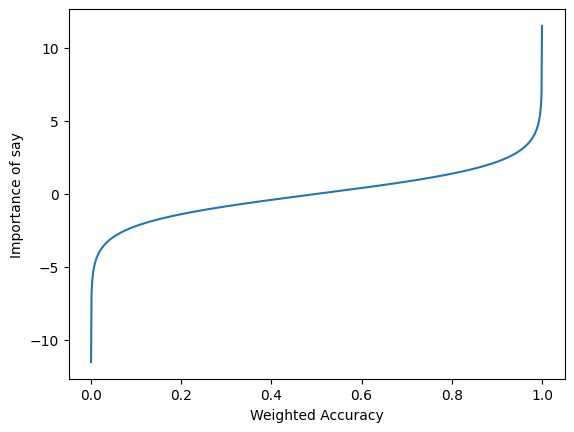

In [11]:
w_acc = np.linspace(1e-5, 1 - 1e-5, 1000)
plt.plot(w_acc, np.log((w_acc / (1 - w_acc))))
plt.xlabel("Weighted Accuracy")
plt.ylabel("Importance of say")
plt.show()

## Prediction

With the importance of say the ensemble of learners $L_1,\dots, L_k$ predicts a label based on the sign of the individual predictions (transformed into -1, 1 labels) weighted with the importance of say $\alpha$: 

\begin{align}
\hat{y}_i = \mathbb{1}\left[\left(\sum_k \alpha_k\cdot (2L_k(x_i) - 1)\right) > 0\right]
\end{align}

Note how an extremely low accuracy (worse than random with 0.5) will lead to a negative importance of say which will in turn invert the sign of the predicton. 

### Task 11

Use the calculated importance of say $\alpha$ from task 10 and predict the labels for the dataset.

Calculate the accuracy on these predictions and compare it to the accuracy of the decision tree (`.score`).

In [20]:
# TODO: predict + compare accuracies
predictions = importance * (2 * model.predict(x) - 1) > 0
accuracy_boosting = np.mean(predictions == y)
accuracy_tree = high_bias_tree.score(x, y)
print(f"Single Tree Boosting Accuracy: {accuracy_boosting:.4f}")
print(f"High bias Tree: {accuracy_tree:.4f}")

Single Tree Boosting Accuracy: 0.5000
High bias Tree: 0.9640


## Adjust weights

After a learner is done learning, we adjust the sample weights for the next learner. Roughly speaking, we want to increase the weights of misclassified samples, so the next learner only performs good if these critical samples are done right.

Let $L$ be the current learner with importance of say $\alpha$ and $w$ be the vector of weights. Then we update each entry $w_i$ with:

\begin{align}
w_i \rightarrow w_i\cdot\exp\left(\alpha\cdot\mathbb{1}[L(x_i) \neq y_i]\right)\,,
\end{align}
where $\mathbb{1}$ is the indicator function.

Note how:

- If we have a very good classifier, we have a large $\alpha$ and we increase the weight of misclassified samples drastically (so they finally get classified correctly with the next classifier)
- If we have a very bad classifier with large negative $\alpha$, we actually have a good classifier that just flips the labels wrong (systematic failure). We account for this with our prediction and can consider these samples well covered by this classifier. Hence we decrease the weight of these samples

The next learner now uses these weights to focus the training on samples with high weight.
This is done by learning on a bootstrap dataset which is draw **according to the weights**. Samples with high weight are drawn more often and hence the learner is more likely to focus on these samples.

### Task 12

Implement the weighted bootstrap sampling function.

Calculate the new weights and draw bootstrap samples according to the old weights and the new adjusted weights.

Similar to task 5, display the densities of the original and bootstrapped data.

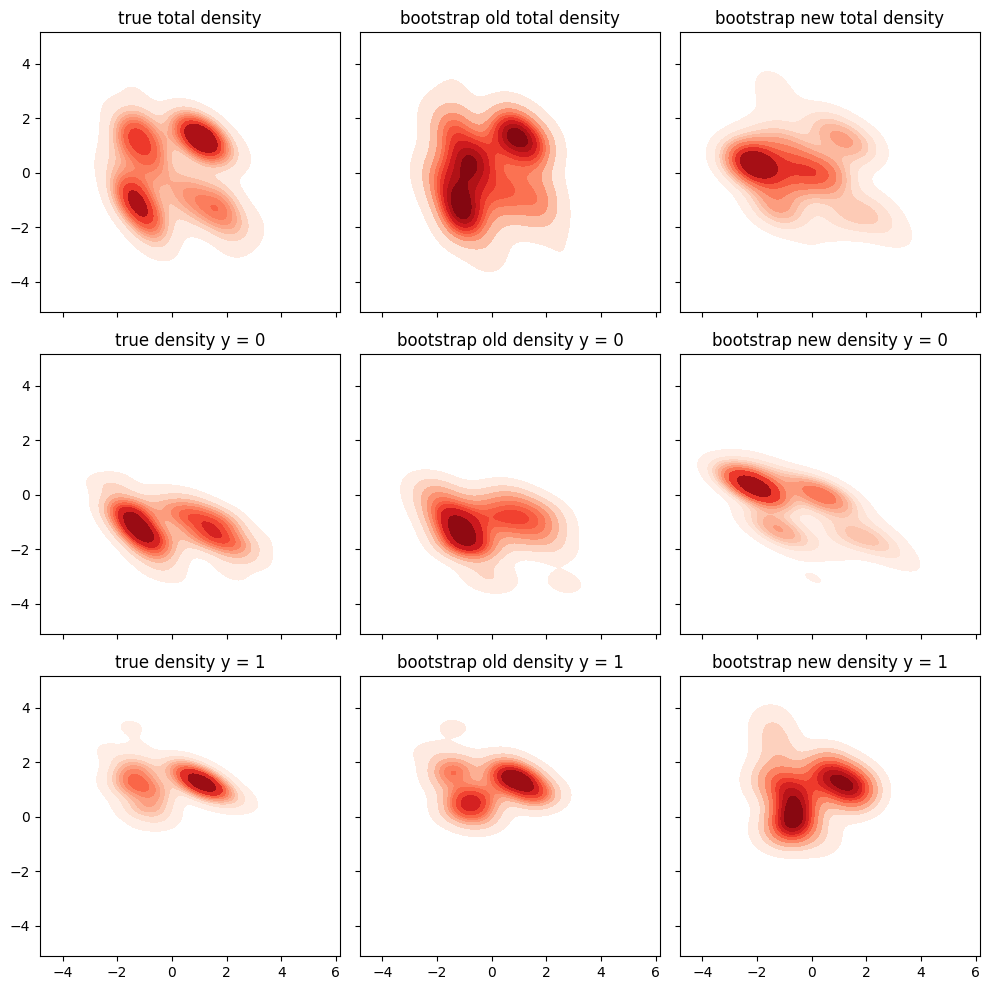

In [21]:
def weighted_sample_bootstrap(x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_], n_samples: int, weights: npt.NDArray[np.float64]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.bool_]]:
    """Creates a weighted bootstrap dataset.

    Parameters
    ----------
    x : npt.NDArray[np.float64]
        Features, shape (n_samples, n_features).
    y : npt.NDArray[np.bool_]
        Labels, shape (n_samples,).
    n_samples : int
        Number of samples in bootstrap dataset.
    weights : npt.NDArray[np.float64]
        Weight for each sample in x, shape (n_samples,).

    Returns
    -------
    tuple[npt.NDArray[np.float64], npt.NDArray[np.bool_]]
        x, y of bootstrap dataset.
    """

    # Normalize weights to form a valid probability distribution (summing to 1)
    p = weights / np.sum(weights)
    
    # Draw indices according to the probability distribution defined by the weights
    used_indices = np.random.choice(x.shape[0], n_samples, replace=True, p=p)
    return x[used_indices, :], y[used_indices]


# Setup for testing weight adjustment
bootstrap_size = 100
current_weights = np.ones(x.shape[0]) / x.shape[0]

# Sample bootstrap data using equal/old weights
x_bootstrap_old, y_bootstrap_old = weighted_sample_bootstrap(x, y, bootstrap_size, current_weights)

# Adjust weights: Exponentially increase weight for incorrectly classified samples
current_weights *= np.exp(importance * (high_bias_tree.predict(x) != y))

# Sample bootstrap data using newly adjusted weights
x_bootstrap_new, y_bootstrap_new = weighted_sample_bootstrap(x, y, bootstrap_size, current_weights)


# TODO: plot densities
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(10, 10))
axes[0][0].set_title("true total density")
axes[0][1].set_title("bootstrap old total density")
axes[0][2].set_title("bootstrap new total density")
axes[1][0].set_title("true density y = 0")
axes[1][1].set_title("bootstrap old density y = 0")
axes[1][2].set_title("bootstrap new density y = 0")
axes[2][0].set_title("true density y = 1")
axes[2][1].set_title("bootstrap old density y = 1")
axes[2][2].set_title("bootstrap new density y = 1")
plot_density(x, ax=axes[0][0])
plot_density(x_bootstrap_old, ax=axes[0][1])
plot_density(x_bootstrap_new, ax=axes[0][2])
plot_density(x[y == 0], ax=axes[1][0])
plot_density(x_bootstrap_old[y_bootstrap_old == 0], ax=axes[1][1])
plot_density(x_bootstrap_new[y_bootstrap_new == 0], ax=axes[1][2])
plot_density(x[y == 1], ax=axes[2][0])
plot_density(x_bootstrap_old[y_bootstrap_old == 1], ax=axes[2][1])
plot_density(x_bootstrap_new[y_bootstrap_new == 1], ax=axes[2][2])
plt.tight_layout()
plt.show()

## Build boosted Ensemble 

Now we have everything to build a Boosted decision tree ensemble.
Starting with equal weights, we perform the following steps for each learner:

1. Bootstrap Dataset according to weights (with the same size as the original dataset)
2. Learn a weak learner
3. Score Performance $\rightarrow$ weight of learner
4. Adjust weights of samples


### Task 13

Implement the Boosting class for decision trees. 

Use scikit learn to compute the crossvalidation scores ($k = 10$) for Boosting with 10 decision trees and maximum depth of 1.

0.968


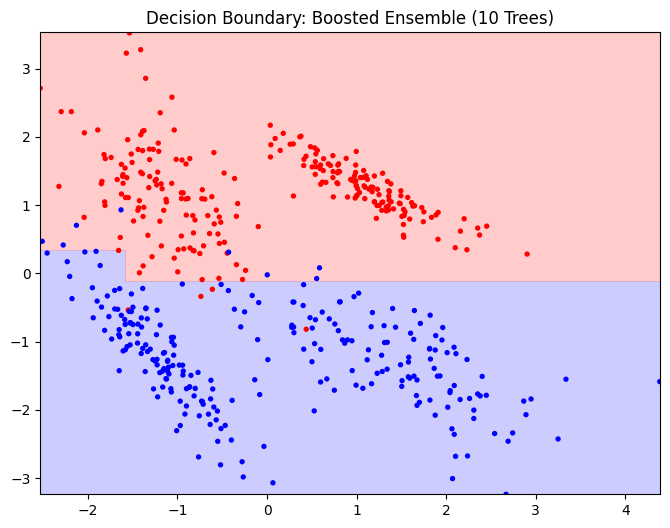

In [22]:
from sklearn.base import BaseEstimator


class DecisionTreeBoosting(BaseEstimator):
    def __init__(self, n_trees: int, **kwargs):
        """Learns ensemble of decision trees with Bagging.

        Parameters
        ----------
        n_trees : int
            Number of decision trees in ensemble.
        **kwargs
            Keyword arguments for DecisionTreeClassifier, such as max_depth. Passed to decision tree creation with `DecisionTreeClassifier(**self.kwargs)`.
        """
        self.n_trees = n_trees
        self.kwargs = kwargs
        self.trees: list[DecisionTreeClassifier] = []
        self.alphas: list[float] = []

    def fit(self, x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_]) -> Self:
        """Learns ensemble of decision trees with Boosting.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).
        y : npt.NDArray[np.bool_]
            Labels, shape (n_samples,).
        """

        # TODO: implement | Already done? Thank you very much
        weights = np.full(x.shape[0], fill_value=1 / x.shape[0])
        self.trees = []
        self.alphas = []
        for _ in range(self.n_trees):
            x_bootstrap, y_bootstrap = weighted_sample_bootstrap(x, y, x.shape[0], weights)
            tree = DecisionTreeClassifier(**self.kwargs).fit(x_bootstrap, y_bootstrap)
            self.trees.append(tree)
            self.alphas.append(importance_of_say(x, y, tree, weights))
            weights *= np.exp(self.alphas[-1] * (tree.predict(x) != y))
        return self

    def predict(self, x: npt.NDArray[np.float64]) -> npt.NDArray[np.bool_]:
        """Given features, predicts labels.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).

        Returns
        -------
        npt.NDArray[np.bool_]
            Predicted labels, shape (n_samples,).
        """

        # TODO: implement | Already done? Thank you very much
        return np.sum([alpha * (2 * tree.predict(x) - 1) for alpha, tree in zip(self.alphas, self.trees)], axis=0) > 0

    def score(self, x: npt.NDArray[np.float64], y: npt.NDArray[np.bool_]) -> float:
        """Accuracy, needed for crossvalidation.

        Parameters
        ----------
        x : npt.NDArray[np.float64]
            Features, shape (n_samples, n_features).
        y : npt.NDArray[np.bool_]
            True labels, shape (n_samples,).

        Returns
        -------
        float
            Accuracy between the true labels and the labels predicted with x.
        """

        # TODO: implement | Already done? Thank you very much
        return np.mean(self.predict(x) == y)


# TODO: crossvalidation 10 trees, max_depth 1, k = 10 | Already done? Thank you very much
n_splits = 10
max_depth = 1
n_trees = 10
model = DecisionTreeBoosting(n_trees=n_trees, max_depth=max_depth)
cv_scores = cross_val_score(model, x, y, cv=n_splits)
print(np.mean(cv_scores))
model.fit(x, y)
plt.figure(figsize=(8, 6))
plt.title("Decision Boundary: Boosted Ensemble (10 Trees)")
plot_decision_boundary(x, y, model)

### Task 14

Similar to task 7, track the average crossvalidation score over 10 tries for an increasing number of trees in the ensemble.

Use $k = 10$ folds and a maximum depth of 1.

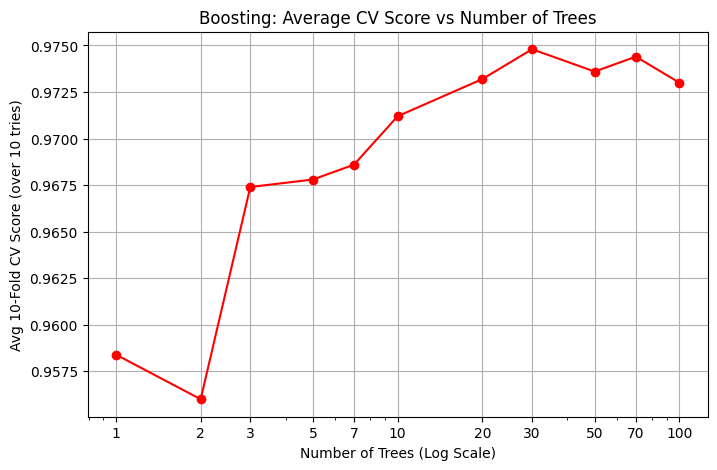

In [23]:
# TODO: increase number of trees, track avg. CV score over 10 tries | Already done? Thank you very much
n_runs = 10
n_splits = 10
max_depth = 1
n_trees_possibilities = [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100]

mean_scores = []
for n_trees in n_trees_possibilities:
    scores = []
    for _ in range(n_runs):
        model = DecisionTreeBoosting(n_trees=n_trees, max_depth=max_depth)
        cv_scores = cross_val_score(model, x, y, cv=n_splits)
        scores.append(np.mean(cv_scores))
    mean_scores.append(np.mean(scores))

plt.figure(figsize=(8, 5))
plt.plot(n_trees_possibilities, mean_scores, marker='o', color='red')
plt.xscale("log")
plt.xticks(n_trees_possibilities, n_trees_possibilities)
plt.title("Boosting: Average CV Score vs Number of Trees")
plt.xlabel("Number of Trees (Log Scale)")
plt.ylabel("Avg 10-Fold CV Score (over 10 tries)")
plt.grid(True)
plt.show()